In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [6]:
# Install Kaggle
!pip install kaggle
import os
# Create a directory for Kaggle
!mkdir -p ~/.kaggle
# Move kaggle.json there
!cp kaggle.json ~/.kaggle/
# Change permissions
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d rohanrao/air-quality-data-in-india


Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
License(s): CC0-1.0
  0% 0.00/72.9M [00:00<?, ?B/s]
100% 72.9M/72.9M [00:00<00:00, 1.37GB/s]


In [8]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
zip_path = "/content/drive/MyDrive/air-quality-data-in-india.zip"
import zipfile





In [10]:
zip_path = "/content/drive/MyDrive/air-quality-data-in-india.zip"
extract_path = "/content/air_quality_data"

import zipfile
import os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")


Extraction complete!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df = pd.read_csv("air_quality_data/city_day.csv")
print("Shape:", df.shape)
df.head()

Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [12]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Remove rows with missing AQI
df_clean = df.dropna(subset=['AQI']).copy()
# View missing values
df_clean.isnull().sum()

,0
City,0
Date,0
PM2.5,678
PM10,7086
NO,387
NO2,391
NOx,1857
NH3,6536
CO,445
SO2,605


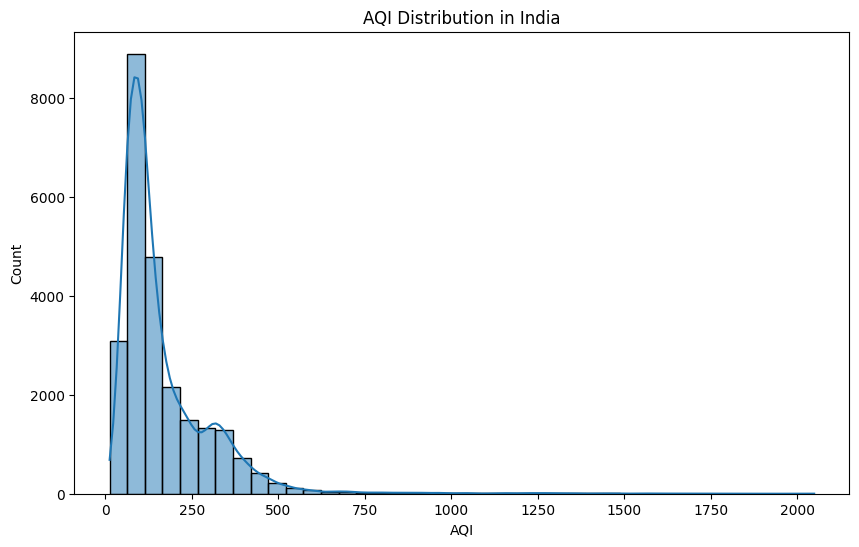

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean['AQI'], bins=40, kde=True)
plt.title("AQI Distribution in India")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Ahmedabad'),
  Text(1, 0, 'Amritsar'),
  Text(2, 0, 'Bengaluru'),
  Text(3, 0, 'Chennai'),
  Text(4, 0, 'Delhi'),
  Text(5, 0, 'Gurugram'),
  Text(6, 0, 'Hyderabad'),
  Text(7, 0, 'Lucknow'),
  Text(8, 0, 'Patna'),
  Text(9, 0, 'Visakhapatnam')])

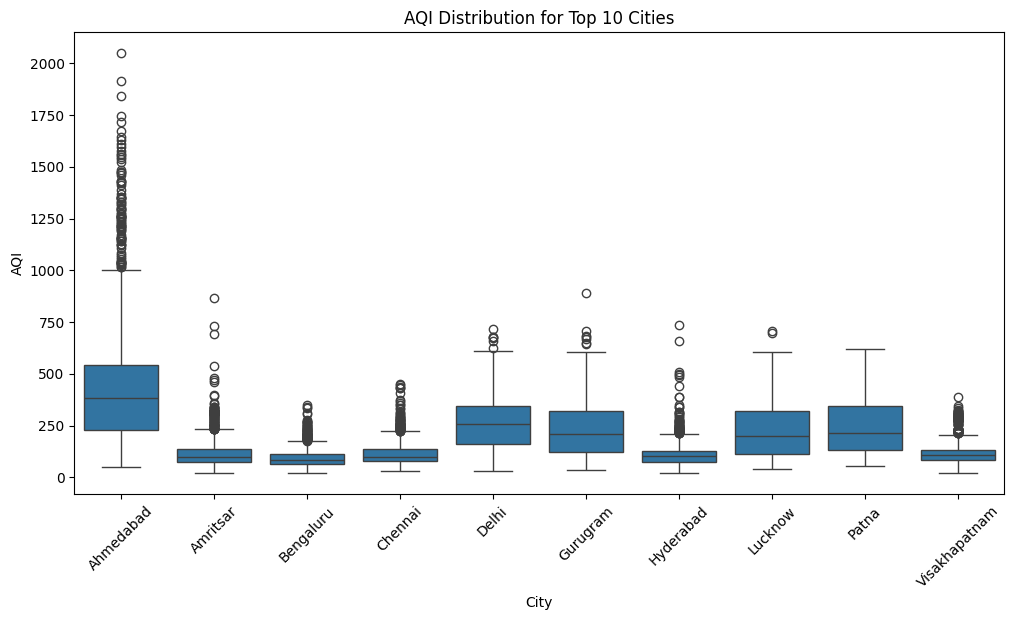

In [14]:
top_cities = df_clean['City'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[df_clean['City'].isin(top_cities)],
x='City', y='AQI')
plt.title("AQI Distribution for Top 10 Cities")
plt.xticks(rotation=45)

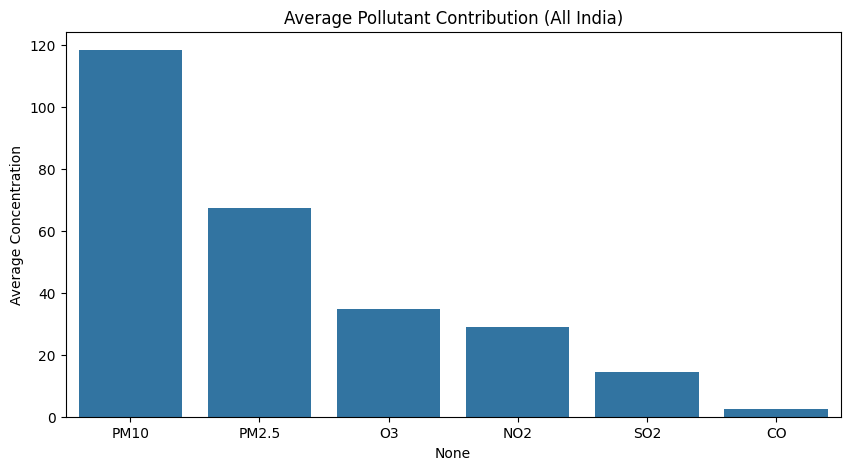

In [15]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
avg_pollution = df_clean[pollutants].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=avg_pollution.index, y=avg_pollution.values)
plt.title("Average Pollutant Contribution (All India)")
plt.ylabel("Average Concentration")
plt.show()

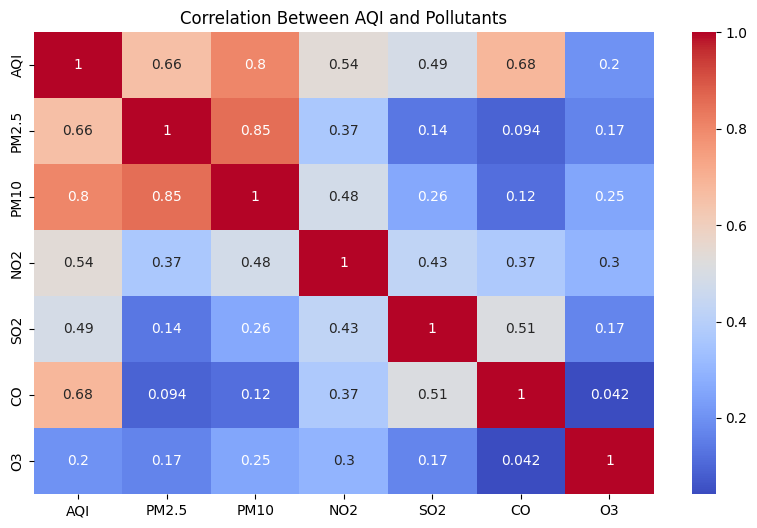

In [16]:
plt.figure(figsize=(10,6))
corr = df_clean[['AQI'] + pollutants].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between AQI and Pollutants")
plt.show()

In [19]:
def categorize_aqi(aqi):
  if aqi <= 50: return "Good"
  elif aqi <= 100: return "Satisfactory"
  elif aqi <= 200: return "Moderate"
  elif aqi <= 300: return "Poor"
  elif aqi <= 400: return "Very Poor"
  else: return "Severe"
df_clean['AQI_Category'] = df_clean['AQI'].apply(categorize_aqi)
df_clean['AQI_Category'].value_counts()

,count
AQI_Category,
Moderate,8829
Satisfactory,8224
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


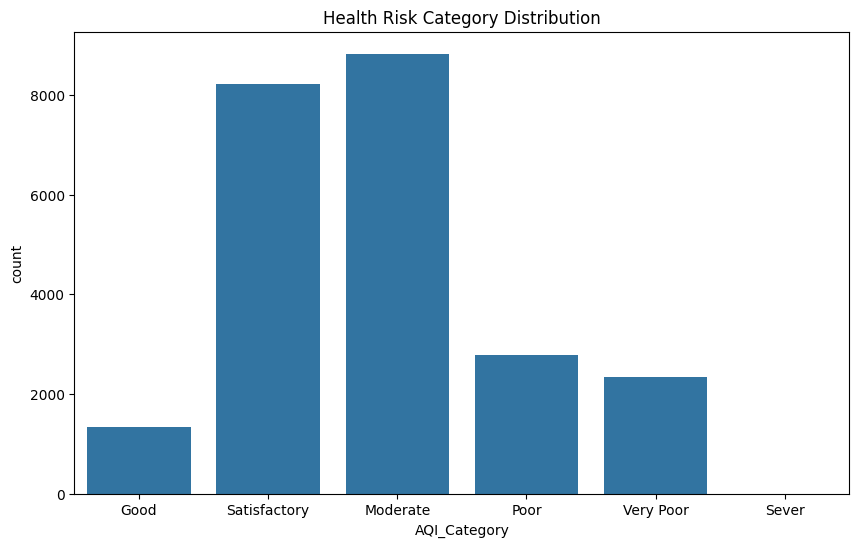

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='AQI_Category', data=df_clean,
order=['Good','Satisfactory','Moderate','Poor','Very Poor','Sever'])
plt.title("Health Risk Category Distribution")
plt.show()

In [22]:
city_aqi = df_clean.groupby('City')['AQI'].mean().sort_values(ascending=False)
city_aqi.head(10)

,AQI
City,
Ahmedabad,452.122939
Delhi,259.487744
Patna,240.782042
Gurugram,225.123882
Lucknow,217.973059
Talcher,172.886819
Jorapokhar,159.251621
Brajrajnagar,150.280505
Kolkata,140.566313


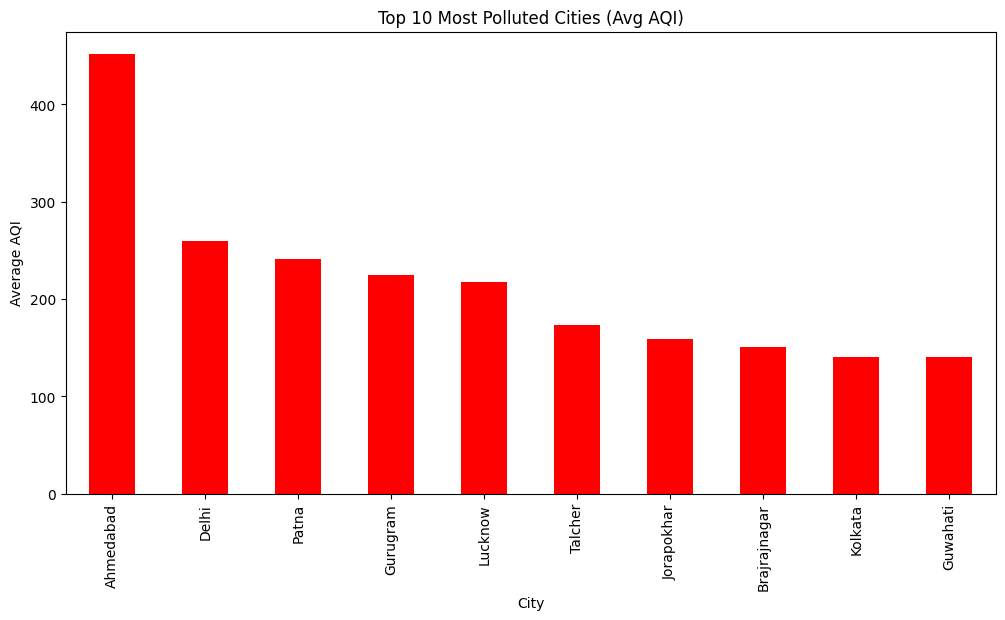

In [23]:
plt.figure(figsize=(12,6))
city_aqi.head(10).plot(kind='bar', color='red')
plt.title("Top 10 Most Polluted Cities (Avg AQI)")
plt.ylabel("Average AQI")
plt.show()

In [24]:
city_pollution = df_clean.groupby('City')[pollutants].mean()
city_pollution['Dominant_Pollutant'] = city_pollution.idxmax(axis=1)
city_pollution['Dominant_Pollutant'].head(10)

,Dominant_Pollutant
City,
Ahmedabad,PM10
Aizawl,PM10
Amaravati,PM10
Amritsar,PM10
Bengaluru,PM10
Bhopal,PM10
Brajrajnagar,PM10
Chandigarh,PM10
Chennai,PM10


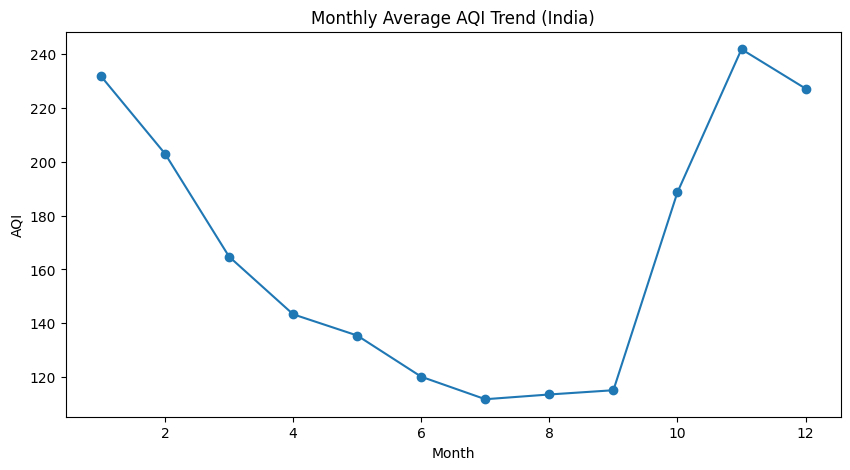

In [28]:
df_clean['Month'] = df_clean['Date'].dt.month
monthly = df_clean.groupby('Month')['AQI'].mean()
plt.figure(figsize=(10,5))
monthly.plot(marker='o')
plt.title("Monthly Average AQI Trend (India)")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

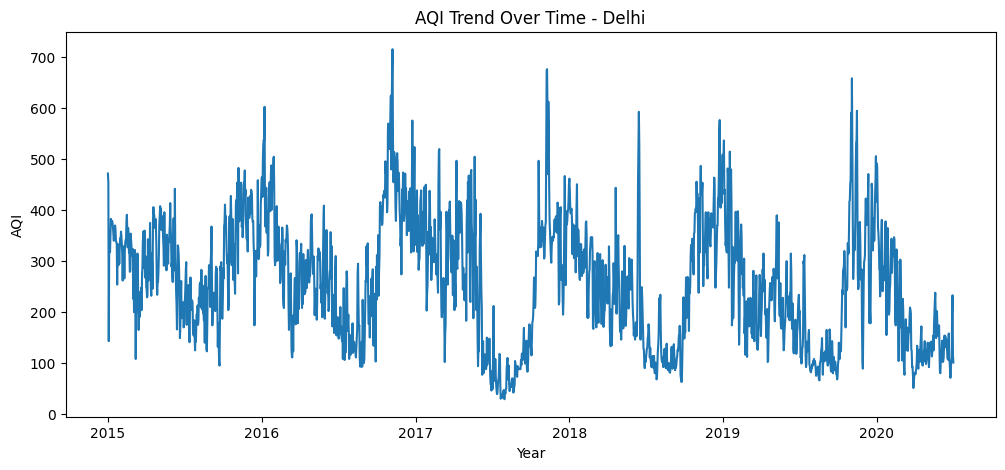

In [26]:
city = "Delhi"  # change to any city
city_df = df_clean[df_clean['City'] == city]
plt.figure(figsize=(12,5))
plt.plot(city_df['Date'], city_df['AQI'])
plt.title(f"AQI Trend Over Time - {city}")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.show()